https://github.com/4GeeksAcademy/alternative-time-series-project/blob/main/solution.ipynb

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from imblearn.metrics import specificity_score
from scipy.stats import randint, uniform
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import pickle
import joblib
from sklearn.metrics import log_loss

In [29]:
# FUNCIONES
## Formato 5 decimales
pd.options.display.float_format = '{:,.5f}'.format 

## Metricas de clasificacion
def metricas_clas(y_train, y_test, y_pred_train, y_pred_test):
    # Calcular métricas para el conjunto de entrenamiento
    train_accuracy = accuracy_score(y_train, y_pred_train)
    train_f1 = f1_score(y_train, y_pred_train)
    train_precision = precision_score(y_train, y_pred_train)
    train_recall = recall_score(y_train, y_pred_train)
    train_specificity = specificity_score(y_train, y_pred_train)

    # Calcular métricas para el conjunto de prueba
    test_accuracy = accuracy_score(y_test, y_pred_test)
    test_f1 = f1_score(y_test, y_pred_test)
    test_precision = precision_score(y_test, y_pred_test)
    test_recall = recall_score(y_test, y_pred_test)
    test_specificity = specificity_score(y_test, y_pred_test)

    # Calcular la diferencia entre métricas de entrenamiento y prueba
    diff_accuracy = train_accuracy - test_accuracy
    diff_f1 = train_f1 - test_f1
    diff_precision = train_precision - test_precision
    diff_recall = train_recall - test_recall
    diff_specificity = train_specificity - test_specificity

    # Crear un DataFrame con los resultados
    metrics_df = pd.DataFrame([[train_accuracy,train_recall,train_specificity,train_precision,train_f1],
                               [test_accuracy, test_recall, test_specificity, test_precision,test_f1],
                               [diff_accuracy, diff_recall, diff_specificity, diff_precision, diff_f1]],
                              columns = ['Accuracy', 'Recall', 'Specificity', 'Precision', 'F1'],
                              index = ['Train','Test', 'Diferencia'])

    return metrics_df

# **0. CONTEXTO Y CARGA DATOS**

Mismo análisis que en ``04-decission-tree.ipynb``, pero aplicando el algoritmo ``Gradient Boosting``

In [31]:
# Cargamos la base de datos
df=pd.read_csv(("diabetes.csv")).drop(columns="Unnamed: 0")
#Hacemos train test split (mismo que en 04-decission-tree.ipynb)
X_train = df.iloc[:608].drop(columns=["Outcome"])
X_test = df.iloc[608:].drop(columns=["Outcome"])
y_train = df["Outcome"].iloc[:608]
y_test = df["Outcome"].iloc[608:]
#Comprobamos split
print(X_train.mean(), "\n","-"*50,"\n",X_test.mean())

Glucose                    121.77236
BloodPressure               71.94767
SkinThickness               29.22852
BMI                         32.50085
DiabetesPedigreeFunction    -0.94391
Age                         33.48520
Pregna/Age                   2.17284
dtype: float64 
 -------------------------------------------------- 
 Glucose                    122.33635
BloodPressure               74.14304
SkinThickness               29.13904
BMI                         32.25229
DiabetesPedigreeFunction    -0.99658
Age                         32.67974
Pregna/Age                   2.21159
dtype: float64


# 1. Entrenamiento del modelo

In [32]:
#Cargamos el rf optimizado
rf=joblib.load(open("RF.joblib", "rb"))
print(rf.get_params)

<bound method BaseEstimator.get_params of RandomForestClassifier(max_depth=17, min_samples_leaf=15, min_samples_split=73,
                       n_estimators=89, random_state=42)>


In [72]:
# Definimos hiperparámetros
param_grid = {
    'learning_rate': uniform(0.05,0.15),
    'loss': ["log_loss", "exponential"],
    'n_estimators': randint(50,150),
    'criterion': ["friedman_mse", "squared_error"],
    'max_depth': randint(2,23),
    'min_samples_leaf': randint(1,60),
    'min_samples_split': randint(2,120)} 

# Configurar GridSearchCV
random_search = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=20,
    scoring='recall',
    cv=5,
    verbose=4,
    n_jobs=-1,
    random_state=42,
)

# Ejecutamos la búsqueda 
random_search.fit(X_train, y_train)
print("Mejores hiperparámetros:")
print(random_search.best_params_)
random_mod = random_search.best_estimator_ #Guardamos los resultados

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores hiperparámetros:
{'criterion': 'friedman_mse', 'learning_rate': np.float64(0.08881699724000254), 'loss': 'exponential', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 7, 'n_estimators': 103}


# 2. Evaluación del modelo

------------------------------------------------------------
GONFIGURACIÓN INICIAL
------------------------------------------------------------
            Accuracy  Recall  Specificity  Precision      F1
Train        0.99836 1.00000      0.99745    0.99539 0.99769
Test         0.83007 0.76471      0.86275    0.73585 0.75000
Diferencia   0.16829 0.23529      0.13470    0.25954 0.24769


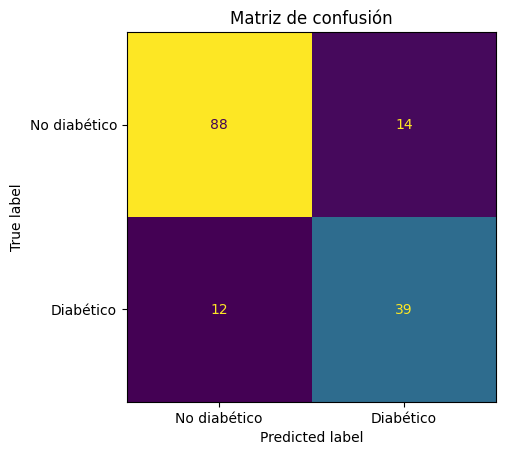

In [73]:
#Predicciones
train_pred = random_mod.predict(X_train)
test_pred = random_mod.predict(X_test)
## Métricas
print("-"*60)
print("GONFIGURACIÓN INICIAL")
print("-"*60)
print(metricas_clas(y_train, y_test, train_pred, test_pred))

##Matriz de confusión
cm = confusion_matrix(y_test, test_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["No diabético", "Diabético"])
disp.plot(cmap="viridis", colorbar=False)
plt.title("Matriz de confusión")
plt.show()

# 3. Optimización de hiperparámetros

In [75]:
# Evolución de la métrica de pérdida de la predicción en cada etapa
loss_train = []

for pred_train in random_mod.staged_predict_proba(X_train):
    loss_train.append(log_loss(y_train, pred_train))

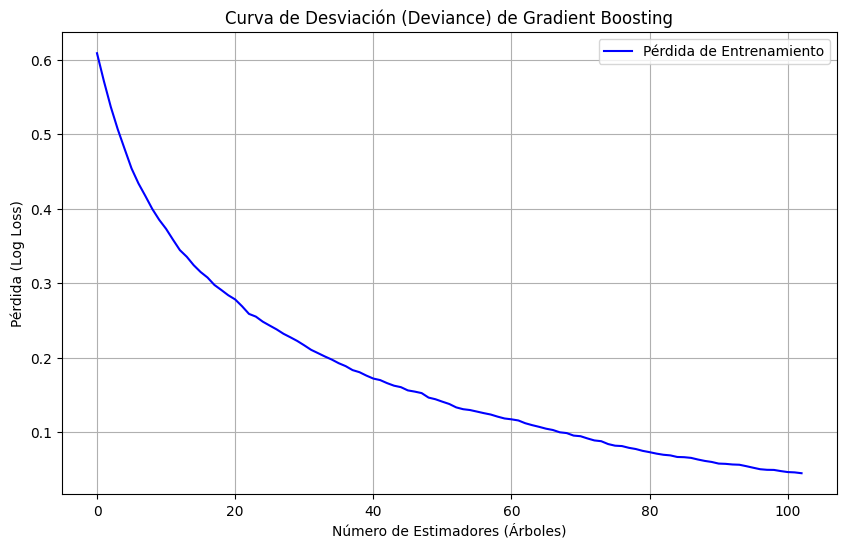

In [76]:
#Visualizamos el proceso
plt.figure(figsize=(10, 6))
plt.plot(loss_train, label='Pérdida de Entrenamiento', color='blue')
plt.title('Curva de Desviación (Deviance) de Gradient Boosting')
plt.xlabel('Número de Estimadores (Árboles)')
plt.ylabel('Pérdida (Log Loss)')
plt.legend()
plt.grid(True)
plt.show()

Podemos observar como el modelo entrenado permite minimizar la medida de error.

# 4. Comparación de las predicciones

In [77]:
#Cargamos los modelos y realizamos predicciones
arboles={"DecissionTree": pickle.load(open("DT.sav", "rb")),
         "RandomForest": rf,
         "GradientBoosting": random_mod}

pred={}
for x,mod in arboles.items():
    pred[f"{x}"]=[mod.predict(X_train),mod.predict(X_test)]

In [85]:
metricas_clas(y_train, y_test, pred[f"DecissionTree"][0], pred[f"DecissionTree"][1])

,Accuracy,Recall,Specificity,Precision,F1
Train,0.79770,0.75926,0.81888,0.69787,0.72727
Test,0.73203,0.76471,0.71569,0.57353,0.65546
Diferencia,0.06567,-0.00545,0.10319,0.12434,0.07181


---

In [80]:
X_test

,Glucose,BloodPressure,SkinThickness,BMI,DiabetesPedigreeFunction,Age,Pregna/Age
608,193.00000,70.00000,31.00000,34.90000,-1.42286,25,3.00000
609,179.00000,70.00000,34.58570,35.10000,-1.60934,37,2.94118
610,163.00000,72.00000,43.73177,39.00000,0.20059,33,0.38462
611,180.00000,90.00000,26.00000,36.50000,-1.15826,35,0.00000
612,89.00000,76.00000,34.00000,31.20000,-1.65016,23,1.66667
...,...,...,...,...,...,...,...
756,68.00000,62.00000,13.00000,20.10000,-1.35858,23,3.33333
757,106.00000,52.00000,28.00255,31.20000,-0.96748,42,2.04545
758,109.00000,80.00000,31.00000,35.90000,0.11966,43,1.52174
759,117.00000,82.27645,24.65250,33.80000,-0.07032,44,0.00000


In [81]:
np.mean(pickle.load(open("DT.sav", "rb")).predict(X_test))

np.float64(0.4444444444444444)

---

In [88]:
for mod,yhat in pred.items():
    print(mod, np.mean(yhat[1]))

DecissionTree 0.4444444444444444
RandomForest 0.27450980392156865
GradientBoosting 0.3464052287581699


In [89]:
for mod,yhat in pred.items():
    print("-"*60)
    print(f"{mod.upper()}")
    print("-"*60)
    print(metricas_clas(y_train, y_test, yhat[0], yhat[1]))

------------------------------------------------------------
DECISSIONTREE
------------------------------------------------------------
            Accuracy   Recall  Specificity  Precision      F1
Train        0.79770  0.75926      0.81888    0.69787 0.72727
Test         0.73203  0.76471      0.71569    0.57353 0.65546
Diferencia   0.06567 -0.00545      0.10319    0.12434 0.07181
------------------------------------------------------------
RANDOMFOREST
------------------------------------------------------------
            Accuracy   Recall  Specificity  Precision       F1
Train        0.78783  0.58796      0.89796    0.76048  0.66319
Test         0.81046  0.62745      0.90196    0.76190  0.68817
Diferencia  -0.02263 -0.03949     -0.00400   -0.00143 -0.02499
------------------------------------------------------------
GRADIENTBOOSTING
------------------------------------------------------------
            Accuracy  Recall  Specificity  Precision      F1
Train        0.99836 1.00000 

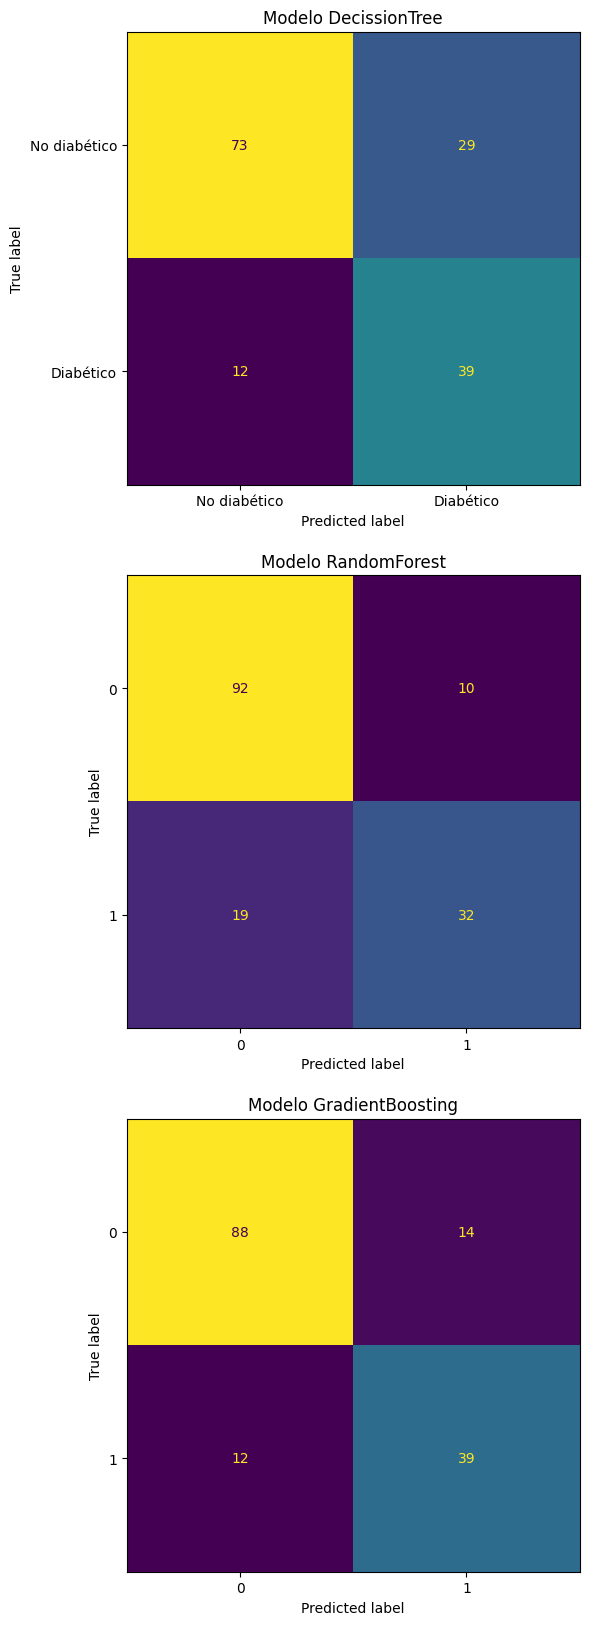

In [93]:
#Matriz de confusión
cm={}

for mod,yhat in pred.items():
    cm[f"{mod}"]=confusion_matrix(y_test, yhat[1])
    
# Representación
fig, axis=plt.subplots(3, figsize=(10,20))
ConfusionMatrixDisplay(confusion_matrix=cm["DecissionTree"], display_labels=["No diabético", "Diabético"]).plot(ax=axis[0],cmap='viridis',colorbar=False)
axis[0].set_title("Modelo DecissionTree")
ConfusionMatrixDisplay(confusion_matrix=cm["RandomForest"]).plot(ax=axis[1],cmap='viridis', colorbar=False)
axis[1].set_title("Modelo RandomForest")
ConfusionMatrixDisplay(confusion_matrix=cm["GradientBoosting"]).plot(ax=axis[2],cmap='viridis', colorbar=False)
axis[2].set_title("Modelo GradientBoosting")
plt.show()

En este caso, podemos observar como el modelo de GradientBoosting permite maximizar los verdaderos afectados, mientras que minimizar conjuntamente falsos afecatdos y no afectados por la enfermedad de estudio (diabetes).